# Muon coincidence rate by numerical integration

This notebook integrates the downward muon intensity over zenith and azimuth. It reads the two 3D scintillator blocks from the GDML and calculates the rate with and without a minimum path length in **each** block.

Run all cells from top to bottom. Requirements: Python, NumPy and Matplotlib. Change the flux, angular exponent and signal calibration in the input cell.

The reference flux is approximately $1\ \mathrm{cm^{-2}\,min^{-1}}$ through a horizontal plane, with normal-area intensity proportional to $\cos^2\theta$ ([PDG 2022, §30.3.1](https://pdgweb.lbl.gov/2022/reviews/rpp2022-rev-cosmic-rays.pdf)). This is a sea-level reference, not a lab measurement.

In [1]:
from pathlib import Path
import importlib.util
import numpy as np
import matplotlib.pyplot as plt

# Find the repository whether the notebook starts here or at its root.
root = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "geometry/dilutiondetector_simplified_fridge.gdml").exists())
spec = importlib.util.spec_from_file_location(
    "geometry_rate", root / "analysis/dilution_detector/geometric_muon_rate.py")
geometry_rate = importlib.util.module_from_spec(spec)
spec.loader.exec_module(geometry_rate)
a, h, b, d = geometry_rate.read_geometry(
    root / "geometry/dilutiondetector_simplified_fridge.gdml")
g = d - h  # cm: gap between facing surfaces

flux = 1.0                   # muons / cm² / minute, integrated horizontal flux
angular_exponent = 2.0        # normal-area intensity I(theta) = I0*cos(theta)**n
reference_amplitude_mv = 20.5
reference_path_mm = 8.0       # ASSUMPTION: confirm this calibration experimentally
threshold_mv = 1.0            # applied separately to BOTH channels

assert flux >= 0 and angular_exponent >= 0
assert reference_amplitude_mv > 0 and reference_path_mm > 0 and threshold_mv >= 0
minimum_path_cm = (reference_path_mm / 10) * threshold_mv / reference_amplitude_mv
print(f"Block x/y/z: {10*a:g} / {10*h:g} / {10*b:g} mm")
print(f"Centre separation: {10*d:g} mm; facing gap: {10*g:g} mm")
print(f"Conditional calibration: {reference_amplitude_mv:g} mV for {reference_path_mm:g} mm")
print(f"Minimum path in each block: {10*minimum_path_cm:.6f} mm")

Block x/y/z: 8 / 8 / 14 mm
Centre separation: 25 mm; facing gap: 17 mm
Conditional calibration: 20.5 mV for 8 mm
Minimum path in each block: 0.390244 mm


## The common position-and-angle integral

For a ray launched at $(x,z)$ on a horizontal reference plane, let $\ell_i(x,z,\theta,\phi)$ be its **actual chord length inside 3D block $i$**. Define $H_i=1$ if $\ell_i>0$, and zero otherwise.

Every geometric rate is an integral of a selection function $S$:

$$
R[S]=60I_0\int_0^{2\pi}\int_0^{\pi/2}\int_{\mathbb R^2}
S(x,z,\theta,\phi)\,\cos^{n+1}\theta\,\sin\theta
\,dx\,dz\,d\theta\,d\phi.
$$

| Calculation | Selection inside the integral |
|---|---|
| Upper block | $S=H_{\rm upper}$ |
| Lower block | $S=H_{\rm lower}$ |
| Both blocks | $S=H_{\rm upper}H_{\rm lower}$ |
| Either block, counting each muon once | $S=H_{\rm upper}+H_{\rm lower}-H_{\rm upper}H_{\rm lower}$ |
| Both above threshold | $S=H_{\rm upper}H_{\rm lower}\,\mathbf{1}[\ell_{\rm upper}\ge L_{\min}]\mathbf{1}[\ell_{\rm lower}\ge L_{\min}]$ |

For fixed direction, the inner position integral is an area:
$$
A_S(\theta,\phi)=\int_{\mathbb R^2}S(x,z,\theta,\phi)\,dx\,dz.
$$
The angular quadratures below use this area to evaluate the same integral efficiently. A final cell also evaluates the full four-dimensional integral numerically using explicit 3D ray–box chords, without using the overlap-area formula.

## Normalize the angular intensity numerically

$\theta$ is measured from downward vertical and $\phi$ is azimuth. Intensity is defined per area **normal to the ray**, so a horizontal area introduces $\cos\theta$, and solid angle introduces $\sin\theta$:

$$
I(\theta)=I_0\cos^n\theta,\qquad
F=2\pi I_0\int_0^{\pi/2}\cos^{n+1}\theta\,\sin\theta\,d\theta.
$$

We evaluate this integral numerically to obtain $I_0$. Gauss–Legendre quadrature approximates an integral with a weighted sum of function evaluations; the order controls the number of points.

In [2]:
def quadrature_interval(low, high, order):
    nodes, weights = np.polynomial.legendre.leggauss(order)
    return low + (nodes + 1) * (high - low) / 2, weights * (high - low) / 2

theta_norm, weights_norm = quadrature_interval(0, np.pi/2, 128)
normalization = 2*np.pi*np.sum(
    weights_norm * np.cos(theta_norm)**(angular_exponent+1) * np.sin(theta_norm))
I0 = flux / normalization
print(f"Numerical angular normalization: {normalization:.9f}")
print(f"I0 = {I0:.9f} muons / cm² / minute / sr")
assert np.isclose(normalization, 2*np.pi/(angular_exponent+2), rtol=1e-10)

Numerical angular normalization: 1.570796327
I0 = 0.636619772 muons / cm² / minute / sr


## Single-block and horizontal-face rates as integrals

For a horizontal rectangular face, $A_{\rm face}=ab$. For the full block, the area from the position integral includes its projected side faces:

$$
A_{\rm single}(\theta,\phi)=ab+hb\tan\theta|\cos\phi|+ha\tan\theta|\sin\phi|.
$$

We evaluate both rates numerically:
$$
R_{\rm face}=60I_0\int_{\Omega_\downarrow}ab\cos^{n+1}\theta\,d\Omega,
\qquad
R_{\rm single}=60I_0\int_{\Omega_\downarrow}A_{\rm single}\cos^{n+1}\theta\,d\Omega.
$$

No closed-form single-block rate is used here. The two blocks have equal single rates because their dimensions are identical and this model has no attenuation.

In [3]:
theta_single, wt_single = quadrature_interval(0, np.pi/2, 256)
phi_single, wp_single = quadrature_interval(0, np.pi/2, 256)
theta_single = theta_single[:, None]
phi_single = phi_single[None, :]
angular_weights = (wt_single[:, None]*wp_single[None, :]
                   * np.cos(theta_single)**(angular_exponent+1)*np.sin(theta_single))
area_single = (a*b + h*b*np.tan(theta_single)*np.cos(phi_single)
               + h*a*np.tan(theta_single)*np.sin(phi_single))
rate_face = float(60*I0*4*np.sum(angular_weights*a*b))
rate_single = float(60*I0*4*np.sum(angular_weights*area_single))
print(f"Horizontal-face integral: {rate_face:.7f} /hour")
print(f"Full upper-block integral: {rate_single:.7f} /hour")
print(f"Full lower-block integral: {rate_single:.7f} /hour")

Horizontal-face integral: 67.2000000 /hour
Full upper-block integral: 120.0000000 /hour
Full lower-block integral: 120.0000000 /hour


## Integrate the full-block coincidence acceptance

Let $[x]_+=\max(0,x)$. For the aligned, equal blocks, the area of allowed trajectories is

$$
A(\theta,\phi;L_{\min})=
\left[a-s\tan\theta\,|\cos\phi|\right]_+
\left[b-s\tan\theta\,|\sin\phi|\right]_+,
\qquad s=g+2L_{\min}\cos\theta.
$$

For a nonzero path cut, set $A=0$ if $L_{\min}\cos\theta>h$.

**Why this includes 3D thickness:** a track must pass through both facing surfaces. To travel at least $L_{\min}$ inside each block, it must also reach a depth $L_{\min}\cos\theta$ into each block. Connecting those two deeper points gives the separation $s$. Side entries and corner-clipping tracks are included whenever their actual chords meet the cut.

The rate per hour is the following numerical double integral:

$$
R(L_{\min})=
60 I_0\int_0^{2\pi}\!\!\int_0^{\pi/2}
A(\theta,\phi;L_{\min})
\cos^{n+1}\theta\,\sin\theta\,d\theta\,d\phi.
$$

By symmetry we integrate one azimuth quadrant and multiply by four. For efficiency, the zenith integration ends at the geometric acceptance boundary:

$$
\theta_{\max}(\phi)=
\arctan\!\left[\min\left(\frac{a}{g\cos\phi},\frac{b}{g\sin\phi}\right)\right].
$$

We split the azimuth interval at $\phi_*=\arctan(b/a)$, where these two limits exchange.

In [4]:
def angular_grid(order):
    # Split at the change of limiting face to keep the geometric boundary smooth.
    split = np.arctan2(b, a)
    phi_parts, weight_parts = [], []
    for low, high in [(0, split), (split, np.pi/2)]:
        p, w = quadrature_interval(low, high, order)
        phi_parts.append(p)
        weight_parts.append(w)
    phi = np.concatenate(phi_parts)[None, :]
    w_phi = np.concatenate(weight_parts)[None, :]
    theta_max = np.arctan(np.minimum(a/(g*np.cos(phi)), b/(g*np.sin(phi))))
    nodes, weights = np.polynomial.legendre.leggauss(order)
    theta = (nodes[:, None]+1) * theta_max/2
    w_theta = weights[:, None] * theta_max/2
    return theta, phi, w_theta*w_phi

def numerical_rate(minimum_path, grid):
    theta, phi, weights = grid
    c = np.cos(theta)
    depth = minimum_path*c
    separation = g + 2*depth
    footprint = (
        np.maximum(0, a-separation*np.tan(theta)*np.cos(phi))
        * np.maximum(0, b-separation*np.tan(theta)*np.sin(phi)))
    footprint = np.where(depth <= h, footprint, 0)
    integrand = footprint * c**(angular_exponent+1) * np.sin(theta)
    return float(60*I0*4*np.sum(weights*integrand))

# Check stability as we increase the number of quadrature points.
print("Order     No threshold [/hour]     With threshold [/hour]")
for order in [64, 128, 256, 512]:
    grid = angular_grid(order)
    uncut = numerical_rate(0, grid)
    cut = numerical_rate(minimum_path_cm, grid)
    print(f"{order:5d} {uncut:24.7f} {cut:26.7f}")
rate_uncut, rate_cut = uncut, cut
print(f"\nReduction: {100*(1-rate_cut/rate_uncut):.3f}%" if rate_uncut else "\nZero input flux.")

Order     No threshold [/hour]     With threshold [/hour]
   64               11.7263639                 11.0416320
  128               11.7263639                 11.0416746
  256               11.7263639                 11.0416694
  512               11.7263639                 11.0416709

Reduction: 5.839%


## Assemble all rate integrals

For two hypothetical zero-thickness centre planes, use $d$ instead of $g$ in the overlap-area integral. This is a comparison with the full-block calculation.

The union selection in the master integral gives
$$
R_{\rm either}=60I_0\int_{\Omega_\downarrow}
(2A_{\rm single}-A_{\rm both})\cos^{n+1}\theta\,d\Omega.
$$
By linearity of integration this equals $2R_{\rm single}-R_{\rm both}$; it does not count a coincident muon twice.

In [5]:
theta_thin, phi_thin, w_thin = angular_grid(512)
area_thin = (np.maximum(0, a-d*np.tan(theta_thin)*np.cos(phi_thin))
             * np.maximum(0, b-d*np.tan(theta_thin)*np.sin(phi_thin)))
rate_thin = float(60*I0*4*np.sum(
    w_thin*area_thin*np.cos(theta_thin)**(angular_exponent+1)*np.sin(theta_thin)))
rate_either = 2*rate_single-rate_uncut
print("Numerical integral                             Muons/hour")
for name, value in [
    ("One horizontal face", rate_face),
    ("Upper full block", rate_single),
    ("Lower full block", rate_single),
    ("Both centre planes (thin approximation)", rate_thin),
    ("Both full blocks", rate_uncut),
    ("Either full block (unique muons)", rate_either),
    ("Both full blocks above threshold", rate_cut),
]:
    print(f"{name:46s} {value:10.5f}")

Numerical integral                             Muons/hour
One horizontal face                              67.20000
Upper full block                                120.00000
Lower full block                                120.00000
Both centre planes (thin approximation)           6.39460
Both full blocks                                 11.72636
Either full block (unique muons)                228.27364
Both full blocks above threshold                 11.04167


## Check against a second numerical integration

The script integrates in trajectory slopes $(u,v)$ rather than angles $(\theta,\phi)$. Agreement checks the angular factors, units and change of variables. Both calculations use numerical quadrature.

In [6]:
slope_uncut = 60*flux*geometry_rate.coincidence_area(a, b, g, angular_exponent, 256)
slope_cut = 60*flux*geometry_rate.coincidence_area(
    a, b, g, angular_exponent, 1024, minimum_path_cm, h)
print(f"Angles: uncut {rate_uncut:.7f}, cut {rate_cut:.7f} /hour")
print(f"Slopes: uncut {slope_uncut:.7f}, cut {slope_cut:.7f} /hour")
assert np.isclose(rate_uncut, slope_uncut, rtol=1e-8, atol=1e-10)
assert np.isclose(rate_cut, slope_cut, rtol=2e-4, atol=1e-5)
print("Independent coordinate integrations agree.")

Angles: uncut 11.7263639, cut 11.0416709 /hour
Slopes: uncut 11.7263639, cut 11.0416714 /hour
Independent coordinate integrations agree.


## Direct numerical integral over positions and 3D paths

As a separate check, evaluate the four-dimensional coincidence integral by Monte Carlo. The horizontal reference plane is halfway between the blocks. Any ray crossing both aligned blocks must cross the rectangle $D=[-a/2,a/2]\times[-b/2,b/2]$ on this plane.

Sample $(x,z)$ uniformly in $D$, $\phi$ uniformly over $[0,2\pi)$, and $\mu=\cos\theta$ with normalized density
$$
p(\mu)=(n+2)\mu^{n+1},\qquad 0\le\mu\le1.
$$

Then the numerical integral is
$$
R[S]=60Fab\int_D\frac{dx\,dz}{ab}
\int_0^{2\pi}\frac{d\phi}{2\pi}\int_0^1p(\mu)S\,d\mu
\approx60Fab\,\frac1N\sum_{j=1}^N S_j.
$$

The code intersects each ray with all six faces of each 3D box and measures the chord. Its uncertainty is numerical Monte Carlo sampling error, not uncertainty in the flux or detector response.

In [7]:
rng = np.random.default_rng(20260924)
samples = 1_000_000
mu = rng.random(samples)**(1/(angular_exponent+2))
phi_mc = rng.uniform(0, 2*np.pi, samples)
tan_theta = np.sqrt(1-mu**2)/mu
u, v = tan_theta*np.cos(phi_mc), tan_theta*np.sin(phi_mc)
x = rng.uniform(-a/2, a/2, samples)
z = rng.uniform(-b/2, b/2, samples)

def box_chord(y_center):
    # t measures downward vertical displacement from the reference plane.
    entry = np.full(samples, -y_center-h/2)
    exit_ = np.full(samples, -y_center+h/2)
    for origin, slope, width in [(x, u, a), (z, v, b)]:
        # Division by zero is harmless for a ray parallel to these faces:
        # its interval is unbounded if the origin is inside the slab.
        with np.errstate(divide="ignore", invalid="ignore"):
            t1 = (-width/2-origin)/slope
            t2 = (width/2-origin)/slope
        entry = np.maximum(entry, np.minimum(t1, t2))
        exit_ = np.minimum(exit_, np.maximum(t1, t2))
    return np.maximum(0, exit_-entry)/mu

upper_path = box_chord(d/2)
lower_path = box_chord(-d/2)
both = (upper_path>0) & (lower_path>0)
above_cut = both & (upper_path>=minimum_path_cm) & (lower_path>=minimum_path_cm)
scale = 60*flux*a*b
for label, selected, quadrature in [
    ("Both blocks", both, rate_uncut),
    ("Both above threshold", above_cut, rate_cut),
]:
    fraction = selected.mean()
    estimate = scale*fraction
    error = scale*np.sqrt(fraction*(1-fraction)/samples)
    print(f"{label}: 4D integral {estimate:.5f} +/- {error:.5f} /hour (1 sigma)")
    print(f"  Angular quadrature: {quadrature:.5f} /hour")
    assert abs(estimate-quadrature) < 5*error+1e-4
print("Full 3D path integration agrees with angular quadrature.")

Both blocks: 4D integral 11.72378 +/- 0.02550 /hour (1 sigma)
  Angular quadrature: 11.72636 /hour
Both above threshold: 4D integral 11.04298 +/- 0.02490 /hour (1 sigma)
  Angular quadrature: 11.04167 /hour
Full 3D path integration agrees with angular quadrature.


## Vary the threshold

This curve holds the geometry, flux and linear calibration fixed. The assumed calibration is **20.5 mV for an 8 mm path** unless you changed it above. A mean pulse height from an unspecified track sample does not establish this calibration.

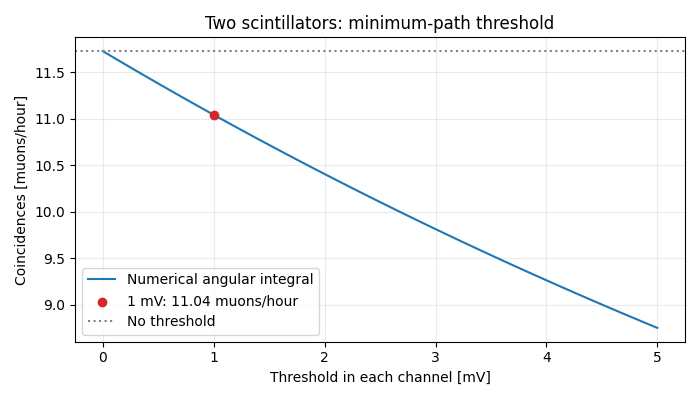

In [8]:
thresholds = np.linspace(0, 5, 41)
plot_grid = angular_grid(256)
rates = np.array([
    numerical_rate((reference_path_mm/10)*t/reference_amplitude_mv, plot_grid)
    for t in thresholds
])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, rates, label="Numerical angular integral")
ax.scatter([threshold_mv], [rate_cut], color="tab:red", zorder=3,
           label=f"{threshold_mv:g} mV: {rate_cut:.2f} muons/hour")
ax.axhline(rate_uncut, color="grey", linestyle=":", label="No threshold")
ax.set(xlabel="Threshold in each channel [mV]",
       ylabel="Coincidences [muons/hour]",
       title="Two scintillators: minimum-path threshold")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

The threshold model uses $L_{\min}=L_{\mathrm{ref}}A_{\mathrm{threshold}}/A_{\mathrm{ref}}$ and assumes the same response in both channels. The rate reduction comes from integrating the accepted trajectories, not directly from the amplitude ratio.

These rates neglect energy-loss and photon-count fluctuations, position-dependent light collection, noise, dead time, and building/fridge attenuation or scattering. Numerical convergence does not quantify these physical uncertainties.